In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats.mstats import normaltest
from scipy.stats import boxcox
from scipy.special import inv_boxcox

In [ ]:
# Load the dataset
import urllib.request
urllib.request.urlretrieve("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML240EN-SkillsNetwork/labs/data/boston_housing_clean.pickle", "boston_housing_clean.pickle")

In [3]:
with open('boston_housing_clean.pickle', 'rb') as to_read:
    boston = pd.read_pickle(to_read)
boston_data = boston['dataframe']
boston_description = boston['description']

In [7]:
print(boston_description)

Boston House Prices dataset

Notes
------
Data Set Characteristics:  

    :Number of Instances: 506 

    :Number of Attributes: 13 numeric/categorical predictive
    
    :Median Value (attribute 14) is usually the target

    :Attribute Information (in order):
        - CRIM     per capita crime rate by town
        - ZN       proportion of residential land zoned for lots over 25,000 sq.ft.
        - INDUS    proportion of non-retail business acres per town
        - CHAS     Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
        - NOX      nitric oxides concentration (parts per 10 million)
        - RM       average number of rooms per dwelling
        - AGE      proportion of owner-occupied units built prior to 1940
        - DIS      weighted distances to five Boston employment centres
        - RAD      index of accessibility to radial highways
        - TAX      full-value property-tax rate per $10,000
        - PTRATIO  pupil-teacher ratio by town
      

    :Attribute Information (in order):
        - CRIM     tỷ lệ tội phạm bình quân đầu người theo thị trấn
        - ZN       tỷ lệ đất ở được quy hoạch cho các lô trên 25.000 sq.ft.
        - INDUS    tỷ lệ diện tích kinh doanh phi bán lẻ trên mỗi thị trấn
        - CHAS     biến giả sông Charles (= 1 nếu khu vực giáp sông; 0 nếu không)
        - NOX      nồng độ oxit nitric (phần trên 10 triệu)
        - RM       số phòng trung bình mỗi căn hộ
        - AGE      tỷ lệ các đơn vị nhà ở có chủ xây dựng trước năm 1940
        - DIS      khoảng cách có trọng số đến năm trung tâm việc làm Boston
        - RAD      chỉ số khả năng tiếp cận các đường cao tốc hướng tâm
        - TAX      mức thuế tài sản toàn giá trị trên $10.000
        - PTRATIO  tỷ lệ học sinh-giáo viên theo thị trấn
        - B        1000(Bk - 0.63)^2 trong đó Bk là tỷ lệ người da đen theo thị trấn
        - LSTAT    % dân số có địa vị thấp hơn
        - MEDV     Giá trị trung bình của nhà ở có chủ sở hữu tính bằng $1000

In [8]:
boston_data.head(30)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2
5,0.02985,0.0,2.18,0.0,0.458,6.430,58.7,6.0622,3.0,222.0,18.7,394.12,5.21,28.7
6,0.08829,12.5,7.87,0.0,0.524,6.012,66.6,5.5605,5.0,311.0,15.2,395.60,12.43,22.9
7,0.14455,12.5,7.87,0.0,0.524,6.172,96.1,5.9505,5.0,311.0,15.2,396.90,19.15,27.1
8,0.21124,12.5,7.87,0.0,0.524,5.631,100.0,6.0821,5.0,311.0,15.2,386.63,29.93,16.5
9,0.17004,12.5,7.87,0.0,0.524,6.004,85.9,6.5921,5.0,311.0,15.2,386.71,17.10,18.9


# Bước 1: Khám phá dữ liệu (EDA)
## 1.1 Thông tin tổng quan

In [9]:
# Kích thước dataset
print("Shape:", boston_data.shape)
print("\n--- Kiểu dữ liệu & giá trị non-null ---")
boston_data.info()


Shape: (506, 14)

--- Kiểu dữ liệu & giá trị non-null ---
<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(14)
memory usage: 55.5 KB


In [10]:
# Thống kê mô tả
boston_data.describe().round(2)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00
mean,3.59,11.36,11.14,0.07,0.55,6.28,68.57,3.80,9.55,408.24,18.46,356.67,12.65,22.53
std,8.60,23.32,6.86,0.25,0.12,0.70,28.15,2.11,8.71,168.54,2.16,91.29,7.14,9.20
min,0.01,0.00,0.46,0.00,0.38,3.56,2.90,1.13,1.00,187.00,12.60,0.32,1.73,5.00
25%,0.08,0.00,5.19,0.00,0.45,5.89,45.02,2.10,4.00,279.00,17.40,375.38,6.95,17.02
50%,0.26,0.00,9.69,0.00,0.54,6.21,77.50,3.21,5.00,330.00,19.05,391.44,11.36,21.20
75%,3.65,12.50,18.10,0.00,0.62,6.62,94.07,5.19,24.00,666.00,20.20,396.22,16.96,25.00
max,88.98,100.00,27.74,1.00,0.87,8.78,100.00,12.13,24.00,711.00,22.00,396.90,37.97,50.00


## 1.2 Kiểm tra Missing Values & Duplicates

In [11]:
# Missing values theo từng cột
missing = boston_data.isnull().sum()
missing_pct = (missing / len(boston_data) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])
print(f"\nTổng missing values: {boston_data.isnull().sum().sum()}")
print(f"Số hàng trùng lặp: {boston_data.duplicated().sum()}")


Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

Tổng missing values: 0
Số hàng trùng lặp: 0


## 1.3 Phân phối các Features (Histogram + Boxplot)

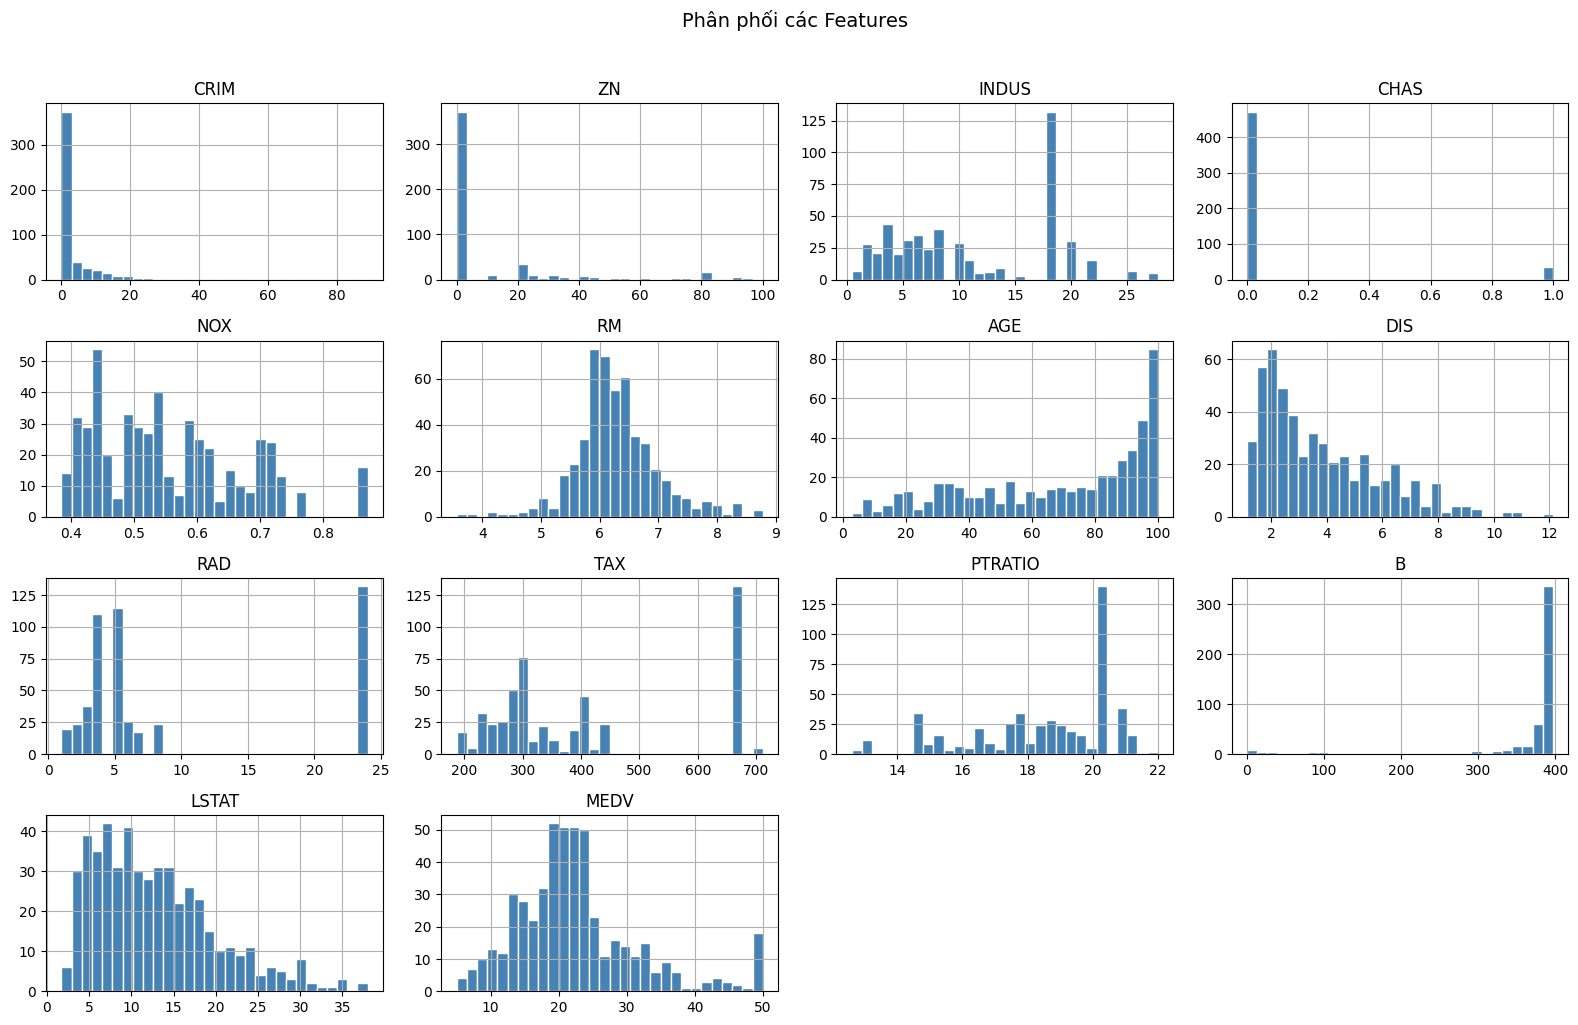

In [12]:
# Histogram tất cả các features
boston_data.hist(bins=30, figsize=(16, 10), color='steelblue', edgecolor='white')
plt.suptitle('Phân phối các Features', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


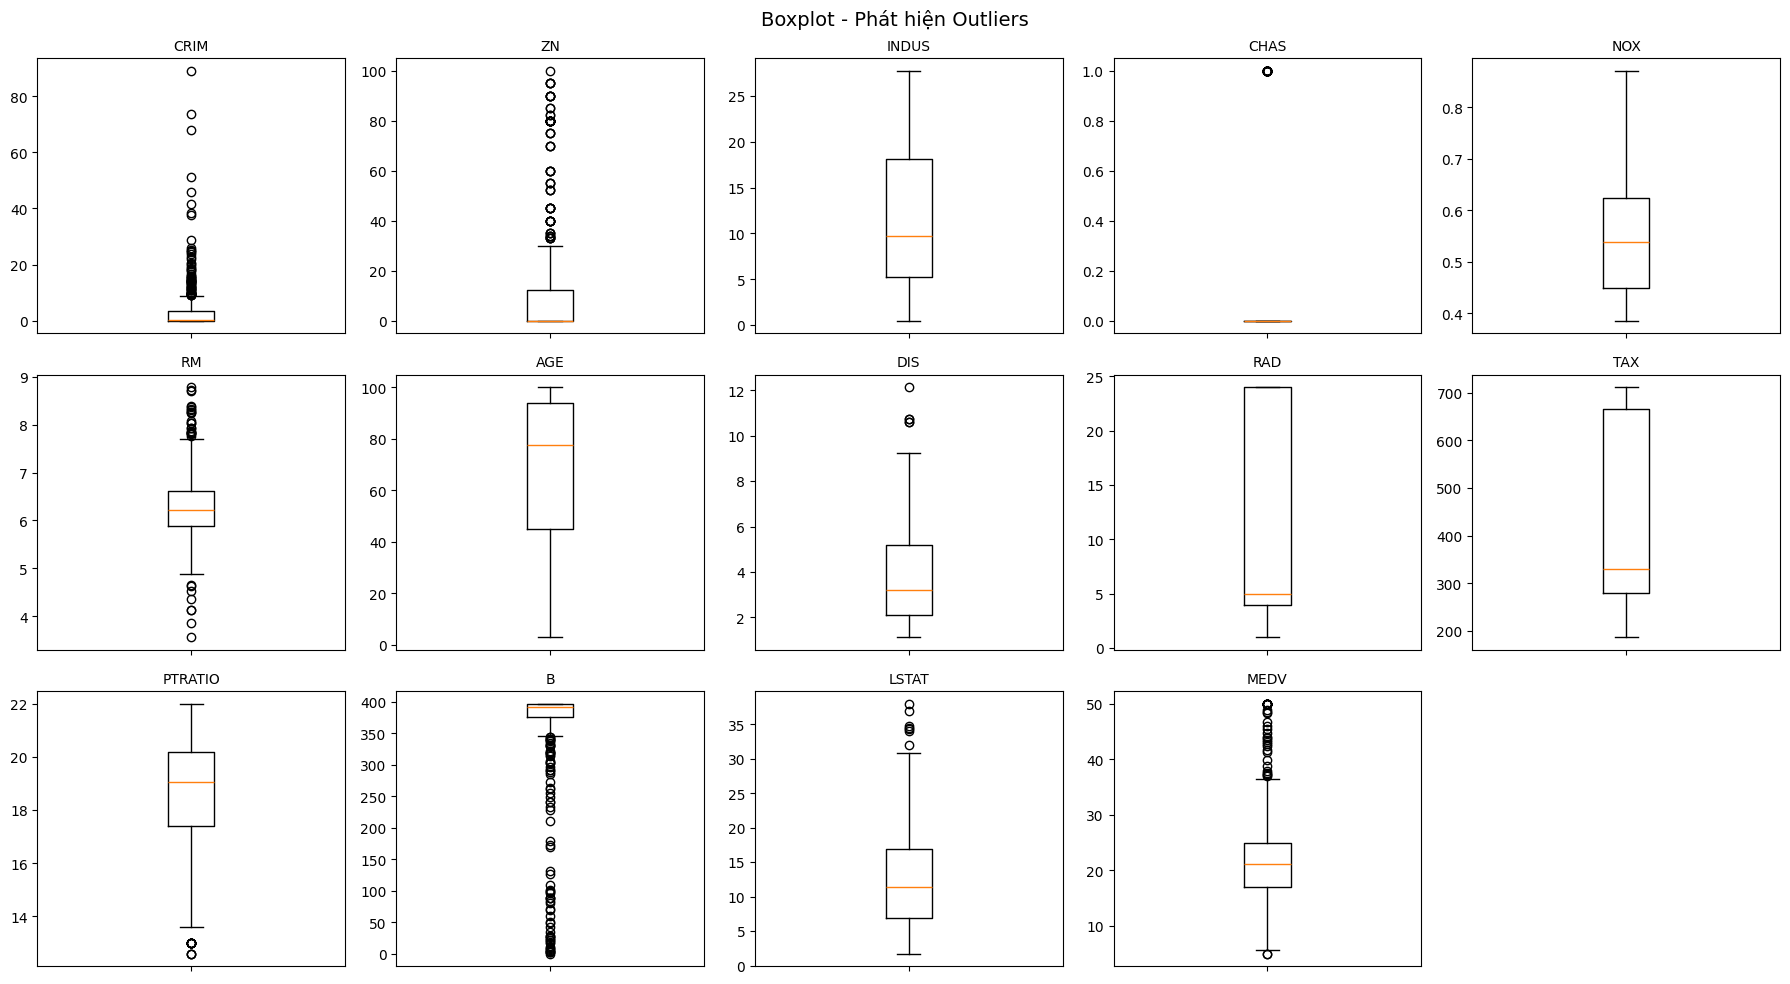

In [13]:
# Boxplot để phát hiện outliers
fig, axes = plt.subplots(3, 5, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(boston_data.columns):
    axes[i].boxplot(boston_data[col].dropna())
    axes[i].set_title(col, fontsize=10)
    axes[i].tick_params(axis='x', labelbottom=False)
# Ẩn subplot dư
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Boxplot - Phát hiện Outliers', fontsize=14)
plt.tight_layout()
plt.show()


## 1.4 Ma trận tương quan (Correlation Heatmap)

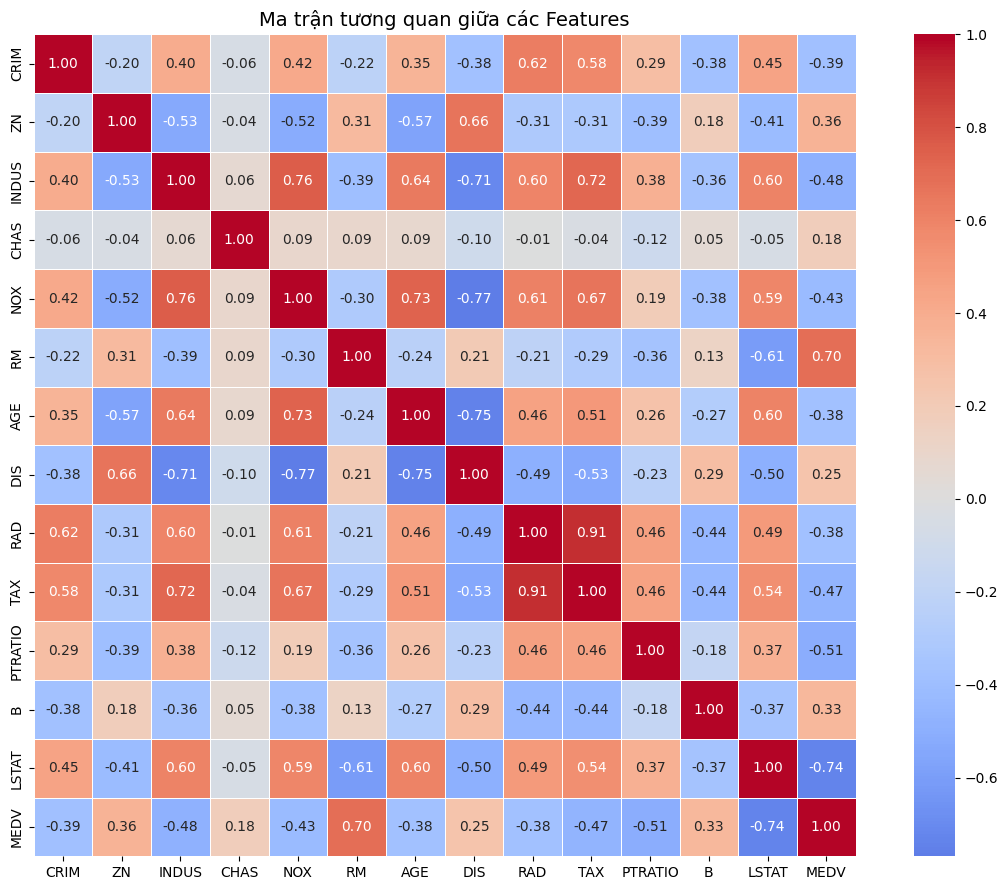

In [14]:
import seaborn as sns

corr_matrix = boston_data.corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True)
plt.title('Ma trận tương quan giữa các Features', fontsize=14)
plt.tight_layout()
plt.show()


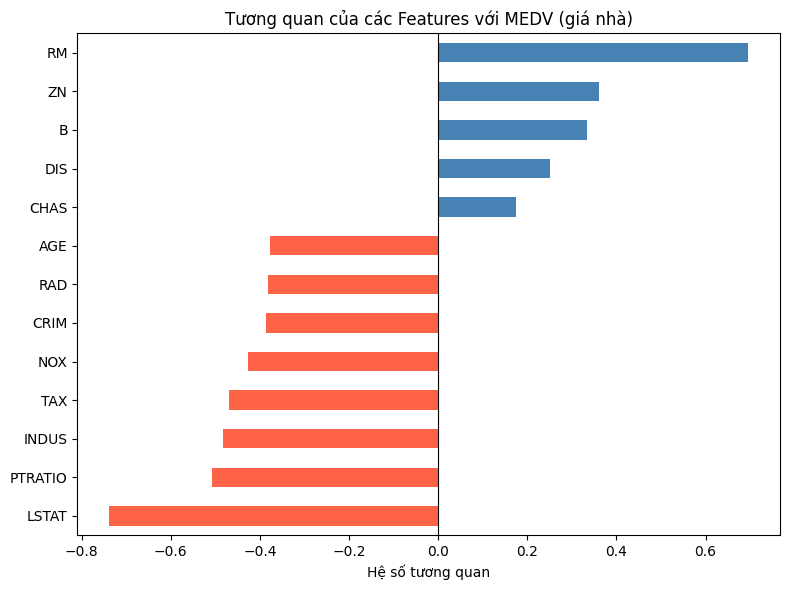

In [15]:
# Tương quan với biến mục tiêu MEDV (giá nhà)
target_corr = corr_matrix['MEDV'].drop('MEDV').sort_values()
plt.figure(figsize=(8, 6))
target_corr.plot(kind='barh', color=['tomato' if v < 0 else 'steelblue' for v in target_corr])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Tương quan của các Features với MEDV (giá nhà)', fontsize=12)
plt.xlabel('Hệ số tương quan')
plt.tight_layout()
plt.show()


# Bước 2: Làm sạch dữ liệu
## 2.1 Xử lý Missing Values

In [16]:
from sklearn.impute import SimpleImputer

# Tách features và target
X = boston_data.drop(columns=['MEDV'])
y = boston_data['MEDV']

# Kiểm tra missing trước khi impute
print("Missing trước impute:\n", X.isnull().sum()[X.isnull().sum() > 0])

# Impute bằng median (robust với outliers hơn mean)
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

print("\nMissing sau impute:", X_imputed.isnull().sum().sum())
print("Shape:", X_imputed.shape)


Missing trước impute:
 Series([], dtype: int64)

Missing sau impute: 0
Shape: (506, 13)


## 2.2 Xử lý Duplicates

In [17]:
# Loại bỏ hàng trùng lặp (nếu có)
df_clean = pd.concat([X_imputed, y.reset_index(drop=True)], axis=1)
n_before = len(df_clean)
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
n_after = len(df_clean)
print(f"Hàng trùng lặp đã xóa: {n_before - n_after}")
print(f"Shape sau khi làm sạch: {df_clean.shape}")

X_clean = df_clean.drop(columns=['MEDV'])
y_clean = df_clean['MEDV']


Hàng trùng lặp đã xóa: 0
Shape sau khi làm sạch: (506, 14)


## 2.3 Phát hiện & Xử lý Outliers (IQR Method)

In [21]:
# Đếm outliers theo phương pháp IQR cho các cột liên tục
def count_outliers_iqr(df, columns=None):
    result = {}
    cols = columns if columns is not None else df.columns
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        n_out = ((df[col] < lower) | (df[col] > upper)).sum()
        result[col] = n_out
    return pd.Series(result).sort_values(ascending=False)

# Nhận diện cột nhị phân (0/1 hoặc 2 giá trị duy nhất) để không xử lý outlier
binary_cols = [col for col in X_clean.columns if X_clean[col].nunique(dropna=True) <= 2]
continuous_cols = [col for col in X_clean.columns if col not in binary_cols]

print("Cột nhị phân sẽ bỏ qua khi xử lý outlier:", binary_cols)

outlier_counts = count_outliers_iqr(X_clean, continuous_cols)
print("\nSố outliers theo IQR (chỉ cột liên tục):\n")
print(outlier_counts[outlier_counts > 0].to_string())

Cột nhị phân sẽ bỏ qua khi xử lý outlier: ['CHAS']

Số outliers theo IQR (chỉ cột liên tục):

B          77
ZN         68
CRIM       65
RM         30
PTRATIO    15
LSTAT       7
DIS         5


In [23]:
# Capping outliers (Winsorization) chỉ áp dụng trên cột liên tục
# Cột nhị phân như CHAS được giữ nguyên để tránh mất thông tin
X_capped = X_clean.copy()
for col in continuous_cols:
    Q1 = X_capped[col].quantile(0.25)
    Q3 = X_capped[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    X_capped[col] = X_capped[col].clip(lower=lower, upper=upper)

print("Đã capping trên", len(continuous_cols), "cột liên tục")
print("Giữ nguyên", len(binary_cols), "cột nhị phân:", binary_cols)
print("Outliers sau capping (chỉ cột liên tục):", count_outliers_iqr(X_capped, continuous_cols).sum())
print("Shape:", X_capped.shape)

Đã capping trên 12 cột liên tục
Giữ nguyên 1 cột nhị phân: ['CHAS']
Outliers sau capping (chỉ cột liên tục): 0
Shape: (506, 13)


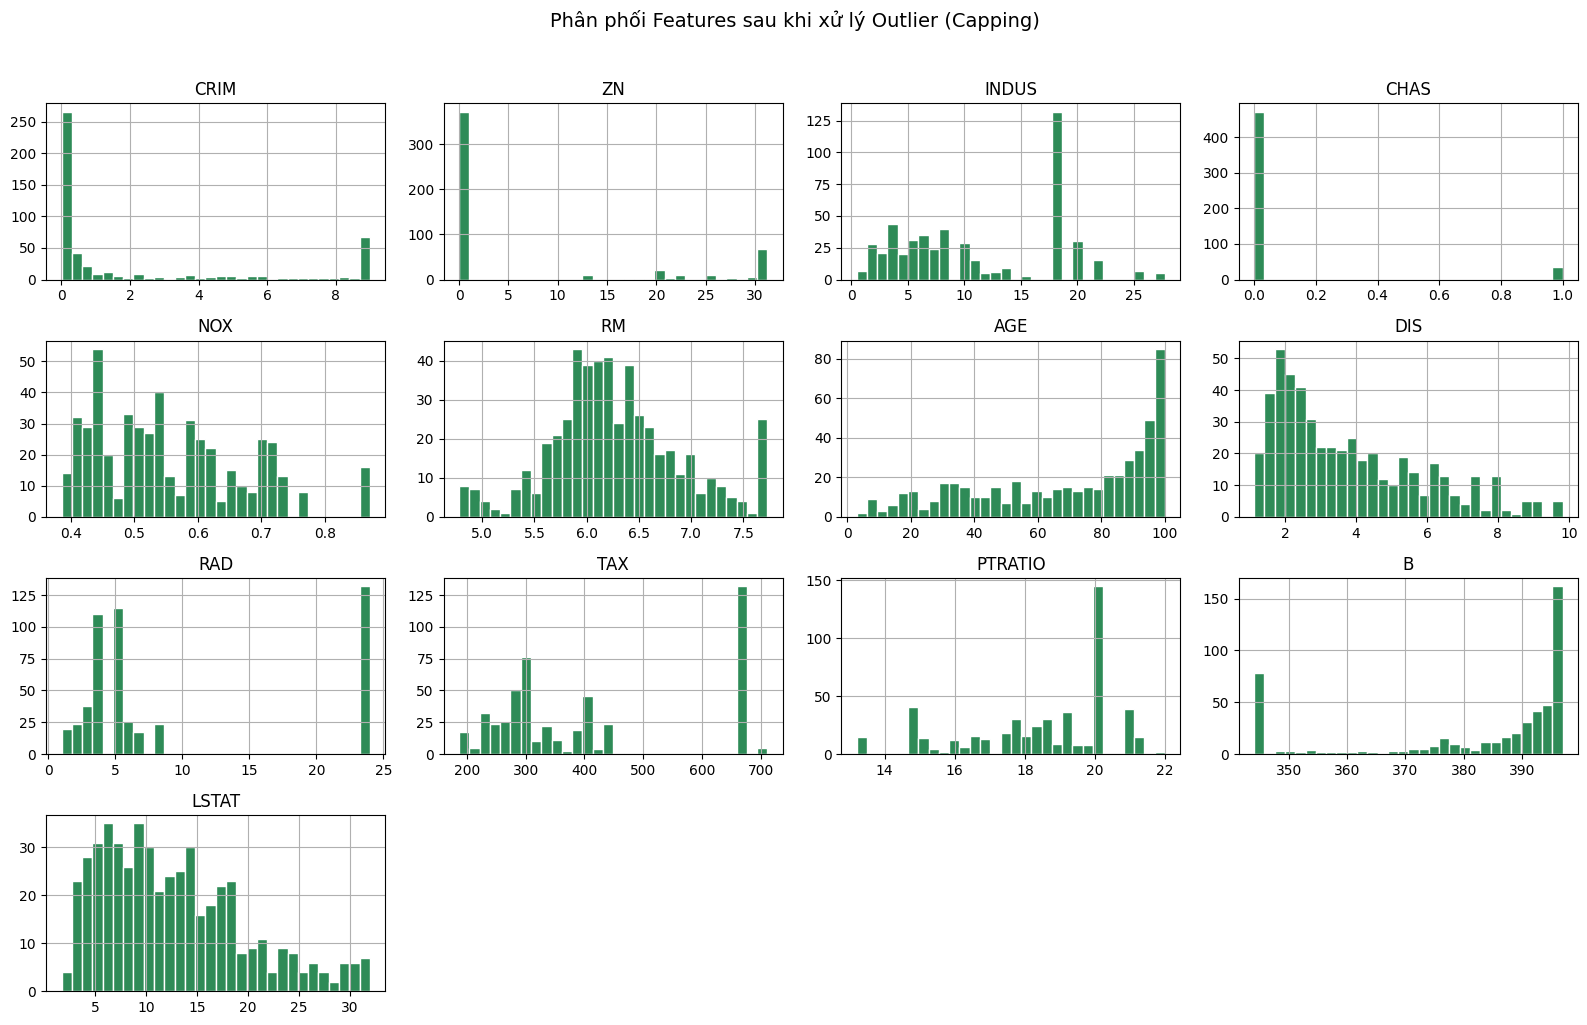

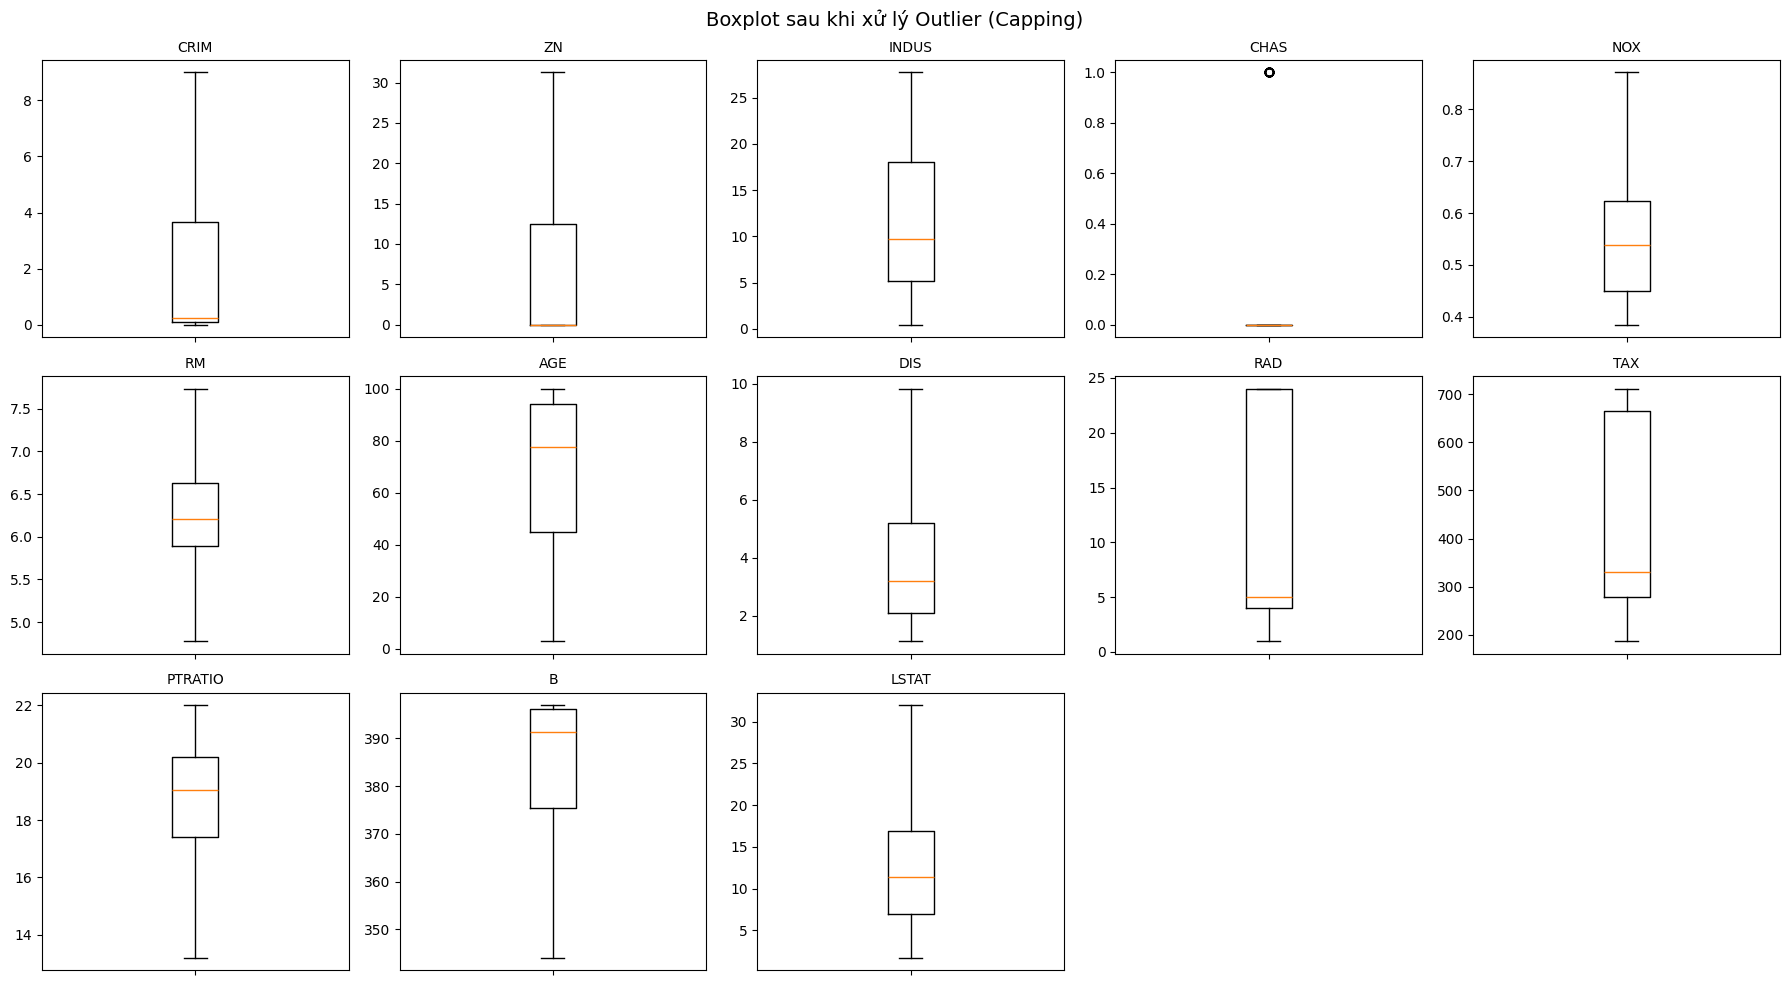

In [24]:
# Histogram dữ liệu sau khi xử lý outlier (X_capped)
X_capped.hist(bins=30, figsize=(16, 10), color='seagreen', edgecolor='white')
plt.suptitle('Phân phối Features sau khi xử lý Outlier (Capping)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Boxplot dữ liệu sau khi xử lý outlier (X_capped)
fig2, axes2 = plt.subplots(3, 5, figsize=(18, 10))
axes2 = axes2.flatten()

for idx, col_name in enumerate(X_capped.columns):
    axes2[idx].boxplot(X_capped[col_name].dropna())
    axes2[idx].set_title(col_name, fontsize=10)
    axes2[idx].tick_params(axis='x', labelbottom=False)

# Ẩn subplot thừa
for k in range(len(X_capped.columns), len(axes2)):
    axes2[k].set_visible(False)

plt.suptitle('Boxplot sau khi xử lý Outlier (Capping)', fontsize=14)
plt.tight_layout()
plt.show()